In [1]:
import pandas as pd
import numpy as np

In [2]:
data= pd.read_excel("Delhi_AQI_2025.xlsx")

In [3]:
col= data.columns.tolist()

In [4]:
for d_col in col:
    print(data[d_col].dtype)

object
object
object
float64
float64
float64
int64
float64
float64
object
object
int64
float64
float64
int64
float64


In [5]:
col

['date_ist',
 'time_ist',
 'location',
 'lat',
 'lon',
 'temp_c',
 'humidity',
 'pressure_mb',
 'windspeed_kph',
 'condition_text',
 'description',
 'aqi_index',
 'pm2_5',
 'pm10',
 'co',
 'no2']

In [6]:
data.head()

,date_ist,time_ist,location,lat,lon,temp_c,humidity,pressure_mb,windspeed_kph,condition_text,description,aqi_index,pm2_5,pm10,co,no2
0,2025-01-01 00:00:00,00:00:00,Anand Vihar,28.6469,77.316,8.1,100,995.4,2.9,Mainly clear,WMO Code 1,197,185.8,188.6,1907,56.7
1,2025-01-01 00:00:00,01:00:00,Anand Vihar,28.6469,77.316,7.7,100,994.7,3.2,Overcast,WMO Code 3,198,174.6,177.4,1669,44.8
2,2025-01-01 00:00:00,02:00:00,Anand Vihar,28.6469,77.316,7.5,100,994.3,4.5,Overcast,WMO Code 3,199,164.4,166.7,1493,34.6
3,2025-01-01 00:00:00,03:00:00,Anand Vihar,28.6469,77.316,7.8,99,994.1,6.0,Overcast,WMO Code 3,200,156.5,158.8,1401,26.7
4,2025-01-01 00:00:00,04:00:00,Anand Vihar,28.6469,77.316,7.3,100,993.8,6.8,Overcast,WMO Code 3,200,149.5,151.8,1372,20.6


In [7]:
# data["date_ist"]= pd.to_datetime(data["date_ist"])

In [8]:
# data.describe()

In [9]:
data.isnull().sum()

date_ist          0
time_ist          0
location          0
lat               0
lon               0
temp_c            0
humidity          0
pressure_mb       0
windspeed_kph     0
condition_text    0
description       0
aqi_index         0
pm2_5             0
pm10              0
co                0
no2               0
dtype: int64

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52560 entries, 0 to 52559
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date_ist        52560 non-null  object 
 1   time_ist        52560 non-null  object 
 2   location        52560 non-null  object 
 3   lat             52560 non-null  float64
 4   lon             52560 non-null  float64
 5   temp_c          52560 non-null  float64
 6   humidity        52560 non-null  int64  
 7   pressure_mb     52560 non-null  float64
 8   windspeed_kph   52560 non-null  float64
 9   condition_text  52560 non-null  object 
 10  description     52560 non-null  object 
 11  aqi_index       52560 non-null  int64  
 12  pm2_5           52560 non-null  float64
 13  pm10            52560 non-null  float64
 14  co              52560 non-null  int64  
 15  no2             52560 non-null  float64
dtypes: float64(8), int64(3), object(5)
memory usage: 6.4+ MB


array([[<Axes: title={'center': 'lat'}>, <Axes: title={'center': 'lon'}>,
        <Axes: title={'center': 'temp_c'}>],
       [<Axes: title={'center': 'humidity'}>,
        <Axes: title={'center': 'pressure_mb'}>,
        <Axes: title={'center': 'windspeed_kph'}>],
       [<Axes: title={'center': 'aqi_index'}>,
        <Axes: title={'center': 'pm2_5'}>,
        <Axes: title={'center': 'pm10'}>],
       [<Axes: title={'center': 'co'}>, <Axes: title={'center': 'no2'}>,
        <Axes: >]], dtype=object)

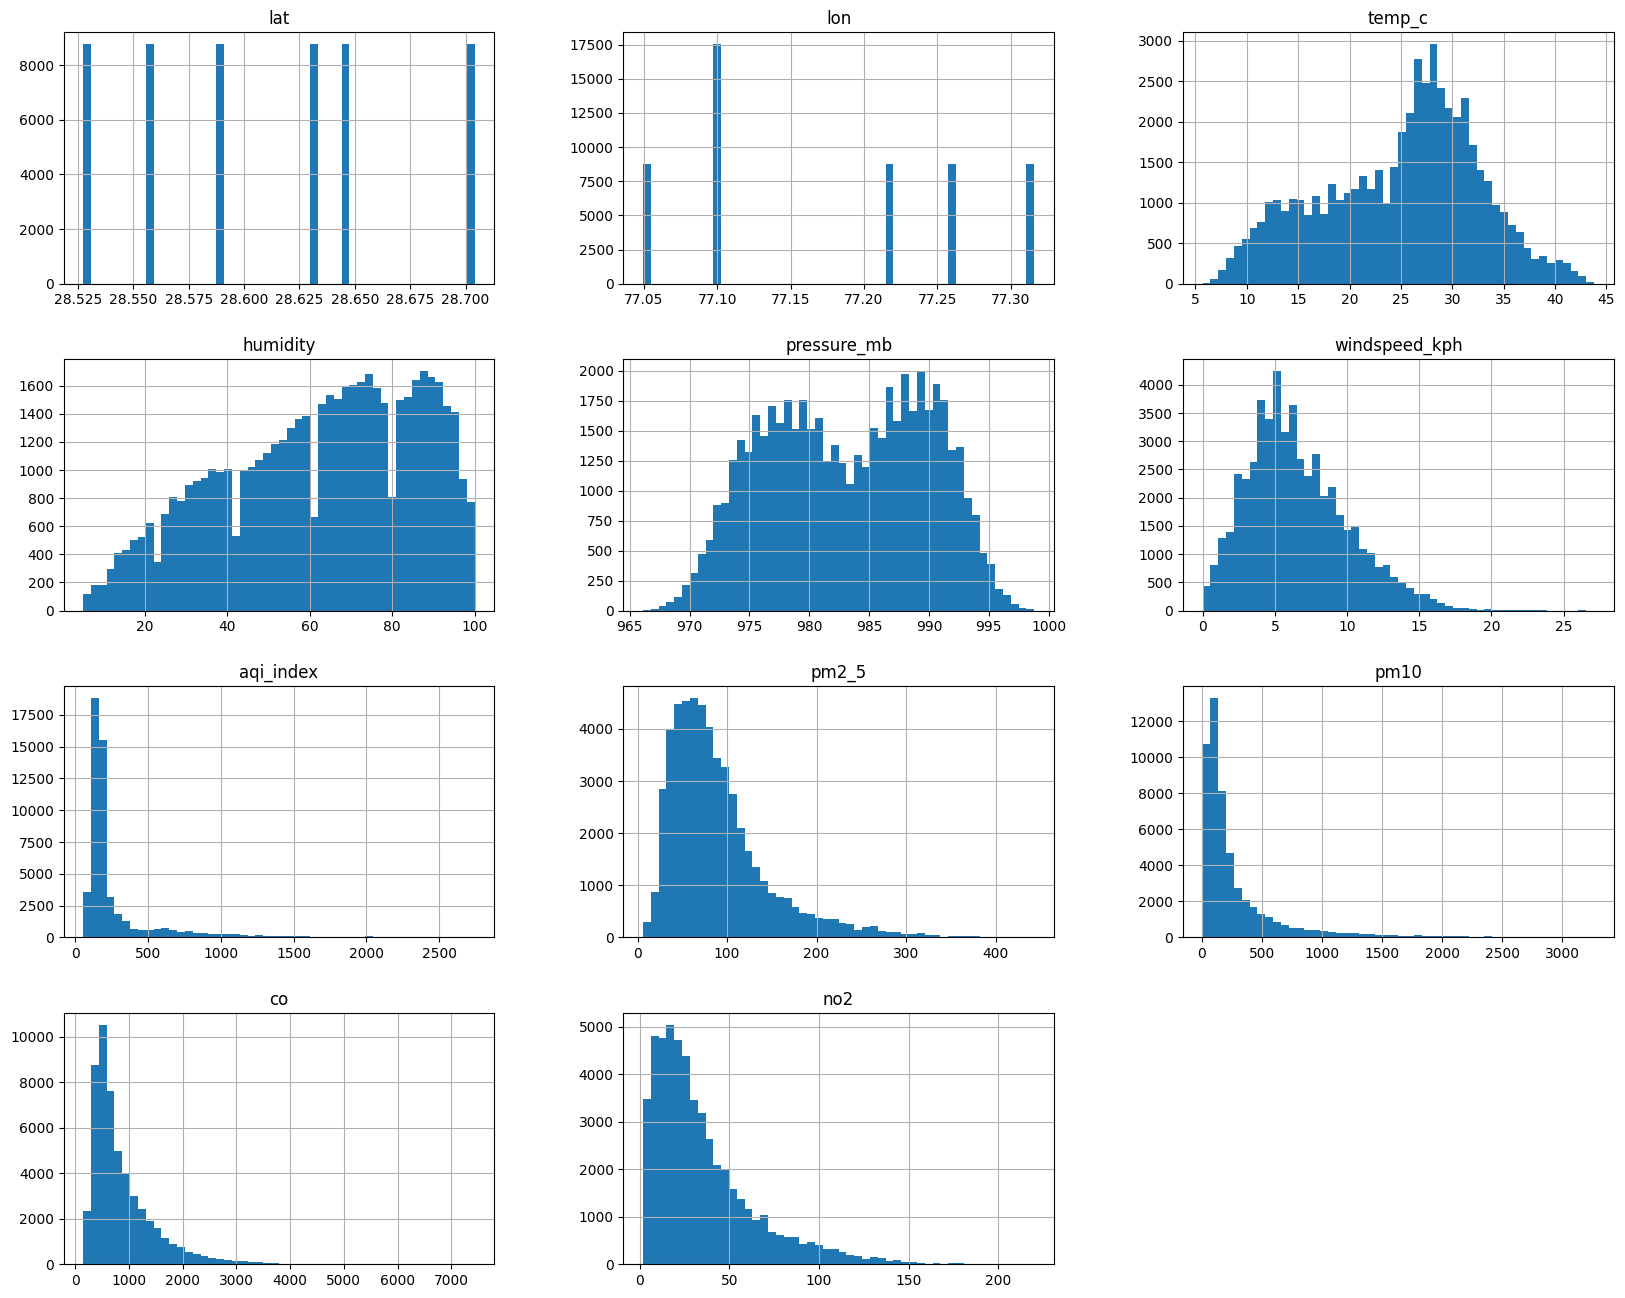

In [11]:
data.hist(bins=50, figsize=(20,16))

In [14]:
data["temp_c"].value_counts()
# fig.title("Temperature_history")

temp_c
27.5    570
27.0    542
28.0    525
26.5    508
28.5    476
       ... 
6.5       2
43.4      2
42.9      2
5.7       1
43.1      1
Name: count, Length: 376, dtype: int64

In [15]:
from sklearn.preprocessing import FunctionTransformer

In [16]:
trf= FunctionTransformer(np.log1p)

In [17]:
data["temp_c"]= trf.fit_transform(data["temp_c"])

In [21]:
data["temp_c"].value_counts()

temp_c
3.349904    570
3.332205    542
3.367296    525
3.314186    508
3.384390    476
           ... 
2.014903      2
3.793239      2
3.781914      2
1.902108      1
3.786460      1
Name: count, Length: 376, dtype: int64

In [22]:
data["date_ist"]= pd.to_datetime(data["date_ist"])

In [23]:
data["year"]= data["date_ist"].dt.year

In [ ]:
data["month"]= data["date_ist"].dt.